# <h1 style="text-align: center;">2. DESCRIPTIVE</h1>

## 1. How elderly is this patient population, and how common is underweight/malnutrition risk, especially among the oldest patients?
### Reasoning:  
Heart failure elderly patients often face malnutrition/cachexia, especially being underweight. So we first check: is the cohort elderly, and is underweight common.

### Metrics used:

Age category – shows risk across age groups

Gender – checks if risk differs by sex

BMI – basic nutrition screening

Underweight flag (BMI < 18.5) – clear risk indicator

### Why these:  
They’re simple, available for all patients, and good first-pass screens for malnutrition risk.

In [2]:
import pandas as pd

df_demography = pd.read_csv("Team05_PyCraft_Cleaned_data/demography_cleaned.csv")
age_order = ['21-29','29-39','39-49','49-59','59-69','69-79','79-89','89-110']

# ============================================================
# KPI GROUP 1: Population Overview
# ============================================================
total_patients = len(df_demography)
pct_female = round((df_demography['gender'] == 'Female').mean() * 100, 1)
pct_male = round((df_demography['gender'] == 'Male').mean() * 100, 1)
pct_elderly = round(df_demography['age_category'].isin(['69-79','79-89','89-110']).mean() * 100, 1)

print("=== KPI 1: POPULATION OVERVIEW ===")
print(f"Total patients:        {total_patients}")
print(f"% Female:              {pct_female}%")
print(f"% Male:                {pct_male}%")
print(f"% Elderly (69+):       {pct_elderly}%")
print()

# ============================================================
# KPI GROUP 2: Age & Gender Distribution (detail table)
# ============================================================
print("=== KPI 2: AGE & GENDER BREAKDOWN ===")
age_gender_table = pd.crosstab(df_demography['age_category'], df_demography['gender']).reindex(age_order)
print(age_gender_table)
print()

# ============================================================
# KPI GROUP 3: Nutritional Risk (BMI-based)
# ============================================================
df_demography['underweight'] = df_demography['bmi'] < 18.5

avg_bmi = round(df_demography['bmi'].mean(), 1)
pct_underweight_overall = round(df_demography['underweight'].mean() * 100, 1)
pct_underweight_oldest = round(
    df_demography[df_demography['age_category'] == '89-110']['underweight'].mean() * 100, 1
)

print("=== KPI 3: NUTRITIONAL RISK (BMI) ===")
print(f"Average BMI (overall):           {avg_bmi} kg/m²")
print(f"% Underweight (overall):         {pct_underweight_overall}%")
print(f"% Underweight (age 89-110):      {pct_underweight_oldest}%")
print()

print("BMI trend by age category:")
print(df_demography.groupby('age_category')['bmi'].mean().reindex(age_order).round(2))
print()

print("% Underweight by age category:")
print((df_demography.groupby('age_category')['underweight'].mean() * 100).reindex(age_order).round(1))

=== KPI 1: POPULATION OVERVIEW ===
Total patients:        2008
% Female:              57.9%
% Male:                42.1%
% Elderly (69+):       72.8%

=== KPI 2: AGE & GENDER BREAKDOWN ===
gender        Female  Male
age_category              
21-29              3     1
29-39              5     7
39-49             18    38
49-59             51    55
59-69            190   178
69-79            421   294
79-89            409   237
89-110            66    35

=== KPI 3: NUTRITIONAL RISK (BMI) ===
Average BMI (overall):           21.3 kg/m²
% Underweight (overall):         25.2%
% Underweight (age 89-110):      36.6%

BMI trend by age category:
age_category
21-29     24.92
29-39     22.41
39-49     22.17
49-59     21.78
59-69     21.48
69-79     21.23
79-89     21.14
89-110    20.85
Name: bmi, dtype: float64

% Underweight by age category:
age_category
21-29      0.0
29-39     25.0
39-49     17.9
49-59     22.6
59-69     22.8
69-79     25.3
79-89     26.0
89-110    36.6
Name: underweight, d

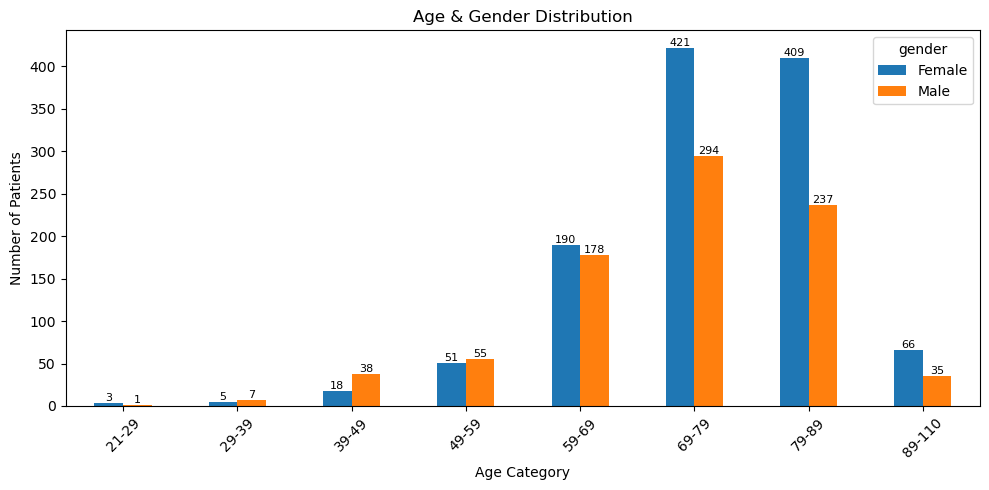

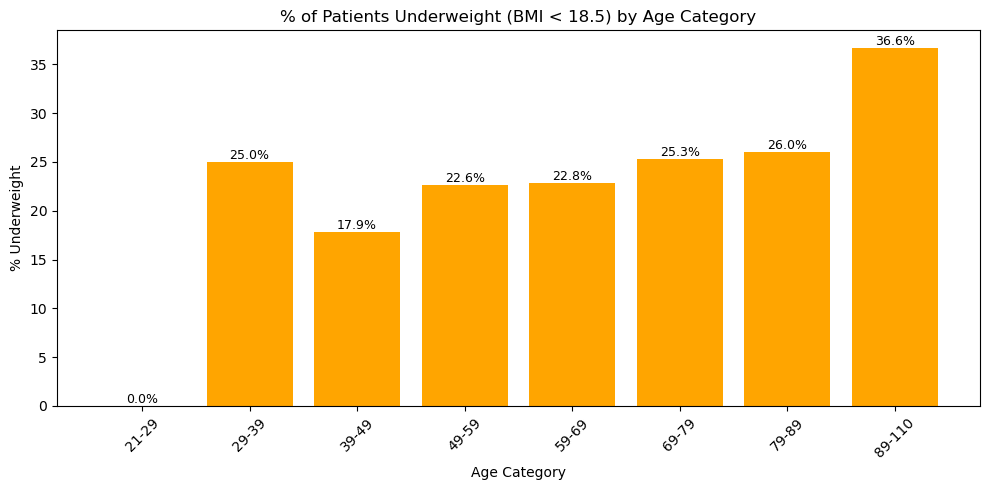

In [4]:
import matplotlib.pyplot as plt

age_order = ['21-29','29-39','39-49','49-59','59-69','69-79','79-89','89-110']

# --- Chart 1: Age & Gender distribution with labels ---
age_gender_table = pd.crosstab(df_demography['age_category'], df_demography['gender']).reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))
age_gender_table.plot(kind='bar', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.title("Age & Gender Distribution")
plt.xlabel("Age Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Chart 2: % Underweight by age category with labels ---
underweight_by_age = (df_demography.groupby('age_category')['underweight'].mean() * 100).reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(underweight_by_age.index, underweight_by_age.values, color='orange')

ax.bar_label(bars, fmt='%.1f%%', fontsize=9)

plt.title("% of Patients Underweight (BMI < 18.5) by Age Category")
plt.xlabel("Age Category")
plt.ylabel("% Underweight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights:

72.8% are 69+ → truly elderly cohort

25.2% underweight overall

36.6% underweight in 89+ → strong age-linked trend

### How it helps:

Shows underweight is a major subgroup, not a minor issue

Justifies using BMI/underweight in predictive models

Supports targeted interventions (e.g., nutrition screening for 79+)

Confirms data cleaning worked (smooth age trend)

## 2. What proportion of patients died during hospitalization vs. were discharged home, and how does that break down by admission ward (ICU, Cardiology, General)? (hospitalization)

### Reasoning

Mortality is the clearest outcome measure — comparing it by ward shows whether sicker patients are actually being placed where they'd get closest monitoring.

What we measured

hospitalization_outcome (Alive/Dead/DischargeAgainstOrder) × admission_ward

In [7]:
import pandas as pd

df_hospitalization = pd.read_csv("Team05_PyCraft_Cleaned_data/hospitalization_discharge_cleaned.csv")

# ============================================================
# KPI GROUP 1: Overall Discharge Outcome
# ============================================================
total_patients = len(df_hospitalization)
pct_died = round((df_hospitalization['hospitalization_outcome'] == 'Dead').mean() * 100, 2)
pct_alive = round((df_hospitalization['hospitalization_outcome'] == 'Alive').mean() * 100, 2)
pct_against_order = round((df_hospitalization['hospitalization_outcome'] == 'DischargeAgainstOrder').mean() * 100, 2)

print("=== KPI 1: OVERALL DISCHARGE OUTCOME ===")
print(f"Total patients:              {total_patients}")
print(f"% Died in-hospital:          {pct_died}%")
print(f"% Discharged alive:          {pct_alive}%")
print(f"% Discharged against order:  {pct_against_order}%")
print()

# ============================================================
# KPI GROUP 2: Outcome by Admission Ward
# ============================================================
print("=== KPI 2: OUTCOME BY ADMISSION WARD ===")
ward_counts = df_hospitalization['admission_ward'].value_counts()
print("Patients per ward:")
print(ward_counts)
print()

outcome_by_ward = (
    pd.crosstab(df_hospitalization['admission_ward'], df_hospitalization['hospitalization_outcome'], normalize='index') * 100
).round(1)
print("Outcome % by ward:")
print(outcome_by_ward)

=== KPI 1: OVERALL DISCHARGE OUTCOME ===
Total patients:              2008
% Died in-hospital:          0.55%
% Discharged alive:          94.12%
% Discharged against order:  5.33%

=== KPI 2: OUTCOME BY ADMISSION WARD ===
Patients per ward:
admission_ward
Cardiology     1547
GeneralWard     265
Others          181
ICU              15
Name: count, dtype: int64

Outcome % by ward:
hospitalization_outcome  Alive  Dead  DischargeAgainstOrder
admission_ward                                             
Cardiology                95.2   0.5                    4.3
GeneralWard               89.8   0.4                    9.8
ICU                       80.0   6.7                   13.3
Others                    92.8   0.6                    6.6


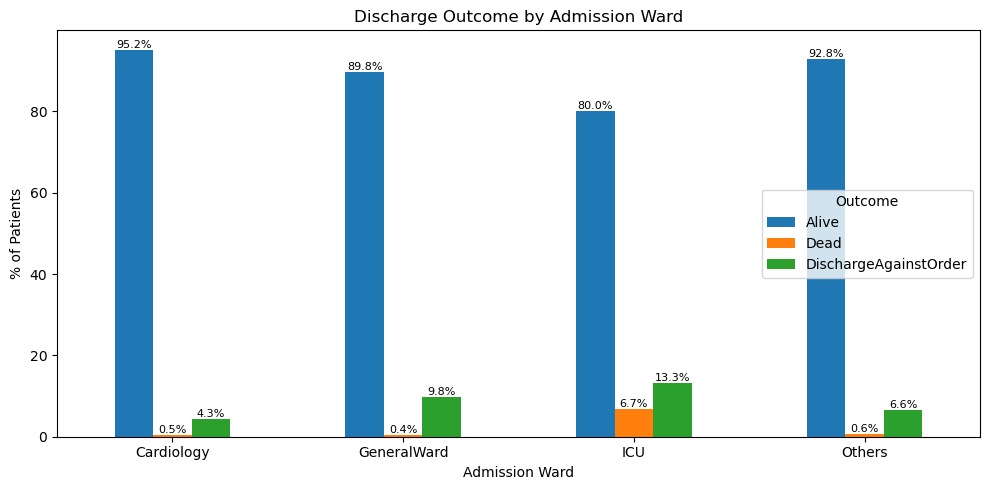

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
outcome_by_ward.plot(kind='bar', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title("Discharge Outcome by Admission Ward")
plt.xlabel("Admission Ward")
plt.ylabel("% of Patients")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

## Insights

Key numbers
Overall in-hospital mortality: 0.55%
ICU mortality: 6.7% (~12x the overall rate)
ICU "discharge against order": 13.3% (highest of all wards)

Insight

Mortality is heavily concentrated in ICU — confirms ward placement reflects real severity, and makes admission_ward a strong feature for later prediction. Caveat: ICU has only 15 patients, so 6.7% = just 1 death — report as "1 of 15," not as a precise rate.


## 3. Which heart failure type is most dangerous
Reasoning:  
Heart failure isn’t one single disease — left, right, and biventricular failure behave differently. Since your cohort is elderly and comorbidity‑heavy, it’s important to check whether the type of heart failure itself is an independent risk factor for death or readmission.

Metrics used:

Heart failure type (Left / Right / Both)

Mortality at 6 months

Readmission at 6 months

LVEF (heart pumping efficiency)

Why these:  
They let you check whether worse outcomes in “Both” are due to true disease mechanism or simply lower pumping efficiency.

In [15]:
import pandas as pd

df_cardiac_complications = pd.read_csv("Team05_PyCraft_Cleaned_data/cardiac_cleaned.csv")
df_hospitalization = pd.read_csv("Team05_PyCraft_Cleaned_data/hospitalization_discharge_cleaned.csv")

merged = df_cardiac_complications.merge(
    df_hospitalization[['patient_id', 'death_6m', 'readmission_6m', 'hospitalization_outcome']],
    on='patient_id', how='left'
)

# ============================================================
# KPI: Risk by Heart Failure Type
# ============================================================
print("=== Patients per heart failure type ===")
print(merged['heart_failure_type'].value_counts())
print()

print("=== 6-month mortality by type ===")
mortality_by_type = (merged.groupby('heart_failure_type')['death_6m'].mean() * 100).round(2)
print(mortality_by_type)
print()

print("=== 6-month readmission by type ===")
readmission_by_type = (merged.groupby('heart_failure_type')['readmission_6m'].mean() * 100).round(2)
print(readmission_by_type)
print()

print("=== Average pumping efficiency (LVEF) by type ===")
print(merged.groupby('heart_failure_type')['heart_pumping_efficiency'].mean().round(1))

=== Patients per heart failure type ===
heart_failure_type
Both     1480
Left      477
Right      51
Name: count, dtype: int64

=== 6-month mortality by type ===
heart_failure_type
Both     3.11
Left     2.31
Right    0.00
Name: death_6m, dtype: float64

=== 6-month readmission by type ===
heart_failure_type
Both     42.23
Left     27.25
Right    35.29
Name: readmission_6m, dtype: float64

=== Average pumping efficiency (LVEF) by type ===
heart_failure_type
Both     50.9
Left     49.5
Right    53.2
Name: heart_pumping_efficiency, dtype: float64


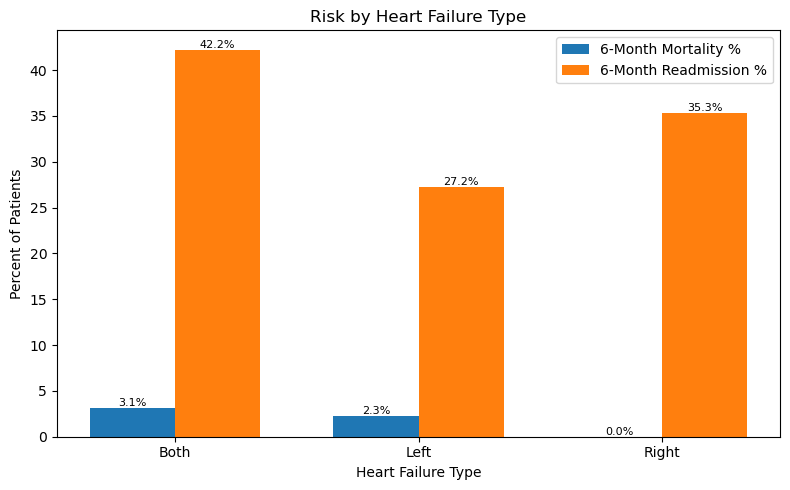

In [16]:
import matplotlib.pyplot as plt

hf_types = merged['heart_failure_type'].dropna().unique().tolist()
mortality_vals = mortality_by_type.reindex(hf_types)
readmission_vals = readmission_by_type.reindex(hf_types)

x = range(len(hf_types))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], mortality_vals, width, label='6-Month Mortality %')
bars2 = ax.bar([i + width/2 for i in x], readmission_vals, width, label='6-Month Readmission %')

ax.bar_label(bars1, fmt='%.1f%%', fontsize=8)
ax.bar_label(bars2, fmt='%.1f%%', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(hf_types)
ax.set_xlabel("Heart Failure Type")
ax.set_ylabel("Percent of Patients")
ax.set_title("Risk by Heart Failure Type")
ax.legend()
plt.tight_layout()
plt.show()

## Insights
Biventricular (“Both”) is the riskiest: highest mortality (3.11%), highest readmission (42.2%), and most common (74%).

Right‑sided shows 0% mortality but has only 51 patients, so the sample is too small to interpret.

LVEF is similar across all types (49–53%), meaning the higher risk in “Both” isn’t just due to worse pumping — the combined left+right involvement adds extra risk.

### How it helps analysis:

Identifies a high‑risk clinical subgroup, not just a demographic one.

Justifies using heart_failure_type as a predictive model feature.

Shows the risk isn’t explained by LVEF alone → the type itself matters.

Sets up next steps: evaluate whether biventricular patients receive appropriately intensive monitoring or treatment.